# Clase 02: Listas, conjuntos, diccionarios y eficiencia

Pregunta guía:

> ¿Cómo podemos observar que una estructura de datos es mejor que otra para cierta operación?

Idea central:

> No existe una estructura de datos mejor en absoluto. Existe una estructura más adecuada para ciertas operaciones.

## Objetivos

Al terminar este notebook podrás:

- Medir tiempos de ejecución en Python.
- Comparar búsqueda en `list` y `set`.
- Usar `dict` para contar frecuencias.
- Usar `collections.Counter`.
- Entender informalmente `O(1)`, `O(n)` y `O(n²)`.
- Explicar qué operación quieres hacer eficiente al elegir una estructura de datos.

## 1. Preparación

Esta celda carga el módulo auxiliar de la clase. Funciona si abres el notebook desde `clase_02/` o desde la carpeta principal del repositorio.

In [1]:
from pathlib import Path
import sys
import time
from collections import Counter

import matplotlib.pyplot as plt

candidatos = [Path.cwd(), Path.cwd().parent, Path.cwd() / 'clase_02']
raiz = next(
    candidato for candidato in candidatos
    if (candidato / 'src' / 'mediciones.py').exists()
)

if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

from src.mediciones import (
    buscar_en_conjunto,
    buscar_en_lista,
    comparar_busquedas_por_tamano,
    contar_con_counter,
    contar_con_diccionario,
    generar_datos,
    medir_tiempo,
)

print(f'Material cargado desde: {raiz}')

Material cargado desde: c:\Users\0286761\Documents\GitHub\EstructurasDatos\clase_02


## 2. Una primera medición con `time.perf_counter`

`time.perf_counter` permite medir intervalos cortos de tiempo. La idea básica es tomar una marca antes, ejecutar la operación y tomar otra marca después.

In [2]:
datos_pequenos = generar_datos(20)
objetivo = -1

inicio = time.perf_counter()
resultado = objetivo in datos_pequenos
fin = time.perf_counter()

print(f'Datos: {datos_pequenos}')
print(f'¿Aparece {objetivo}? {resultado}')
print(f'Tiempo medido: {fin - inicio:.10f} segundos')

Datos: [1, 0, 4, 3, 3, 2, 1, 8, 1, 9, 6, 0, 0, 1, 3, 3, 8, 9, 0, 8]
¿Aparece -1? False
Tiempo medido: 0.0000288000 segundos


### Pregunta

¿Por qué una medición tan pequeña puede variar si ejecutas la celda varias veces?
porque por la forma en la que creamos generar_datos el dato no siempe se va a encontrar en el mismo lugar, va a ir variando cada vez que la generemos

## 3. Función `medir_tiempo`

Usaremos una función que ejecuta varias veces una operación y regresa el tiempo promedio. Esta es la versión base que también aparece en la presentación.

In [3]:
def medir_tiempo_base(funcion, repeticiones=10):
    tiempos = []

    for _ in range(repeticiones):
        inicio = time.perf_counter()
        funcion()
        fin = time.perf_counter()
        tiempos.append(fin - inicio)

    return sum(tiempos) / len(tiempos)


tiempo = medir_tiempo_base(lambda: objetivo in datos_pequenos, repeticiones=10)
print(f'Tiempo promedio: {tiempo:.10f} segundos')

Tiempo promedio: 0.0000004400 segundos


## 4. Búsqueda en `list`

Una lista mantiene orden y repeticiones. Para saber si un valor aparece, Python puede tener que revisar muchos elementos.

In [4]:
n = 100_000
datos = generar_datos(n)
objetivo_presente = datos[-1]
objetivo_ausente = -1

tiempo_lista_presente = medir_tiempo(
    lambda: buscar_en_lista(datos, objetivo_presente),
    repeticiones=10,
)
tiempo_lista_ausente = medir_tiempo(
    lambda: buscar_en_lista(datos, objetivo_ausente),
    repeticiones=10,
)

print(f'Lista con {n:,} elementos')
print(f'Objetivo presente: {tiempo_lista_presente:.8f} segundos')
print(f'Objetivo ausente:  {tiempo_lista_ausente:.8f} segundos')

Lista con 100,000 elementos
Objetivo presente: 0.00003592 segundos
Objetivo ausente:  0.00073880 segundos


### Pregunta

Cuando el objetivo está ausente, ¿qué tiene que ocurrir antes de que Python pueda responder `False`?
El algoritmo tiene que bscar en toda la lista el dato y una vez que lo hace nos dice que si se encuentra en el o no, en este caso nunca se va a encontrar

## 5. Búsqueda en `set`

Un conjunto está diseñado para pertenencia. El costo promedio de preguntar `x in conjunto` suele comportarse como aproximadamente constante respecto al tamaño.

In [5]:
conjunto = set(datos)

tiempo_set_presente = medir_tiempo(
    lambda: buscar_en_conjunto(conjunto, objetivo_presente),
    repeticiones=10,
)
tiempo_set_ausente = medir_tiempo(
    lambda: buscar_en_conjunto(conjunto, objetivo_ausente),
    repeticiones=10,
)

print(f'Tamaño de la lista:    {len(datos):,}')
print(f'Tamaño del conjunto: {len(conjunto):,}')
print(f'Set, objetivo presente: {tiempo_set_presente:.10f} segundos')
print(f'Set, objetivo ausente:  {tiempo_set_ausente:.10f} segundos')

Tamaño de la lista:    100,000
Tamaño del conjunto: 10,000
Set, objetivo presente: 0.0000004100 segundos
Set, objetivo ausente:  0.0000002200 segundos


### Preguntas

1. ¿Por qué el conjunto puede tener menos elementos que la lista?
    Porque lo que esta contando el conjunto es el número de listas no el numero de elementos asi que si tenemos 100 listas con 10 elementos, el tamaño de las listas va a ser de 1000 y el tamñano del cnjunto a a ser de 100
2. ¿Qué sacrificios tiene usar un `set` si la lista original tenía orden y duplicados?
    Se pierde tanto el rden como los duplicados, ya que esa una de las caracteristicas de los conjuntos
3. ¿Para qué operación parece más adecuado el conjunto?
    Para cuando queramos medir muchisimos datos ya que tarda substancialmente menos

## 6. Comparar varios tamaños

Ahora compararemos búsqueda de un valor ausente con varios tamaños de entrada. El objetivo ausente ayuda a observar el costo de revisar toda la lista.

In [72]:
tamanos = [1_000, 5_000, 10_000, 50_000, 100_000, 200_000]
resultados = comparar_busquedas_por_tamano(tamanos, repeticiones=8)

print('tamaño      lista (s)       set (s)')
for fila in resultados:
    print(f"{fila['tamano']:>7,}   {fila['tiempo_lista']:>11.8f}   {fila['tiempo_conjunto']:>11.8f}")

tamaño      lista (s)       set (s)
  1,000    0.00000864    0.00000026
  5,000    0.00005754    0.00000020
 10,000    0.00010623    0.00000021
 50,000    0.00036403    0.00000029
100,000    0.00073410    0.00000041
200,000    0.00131290    0.00000030


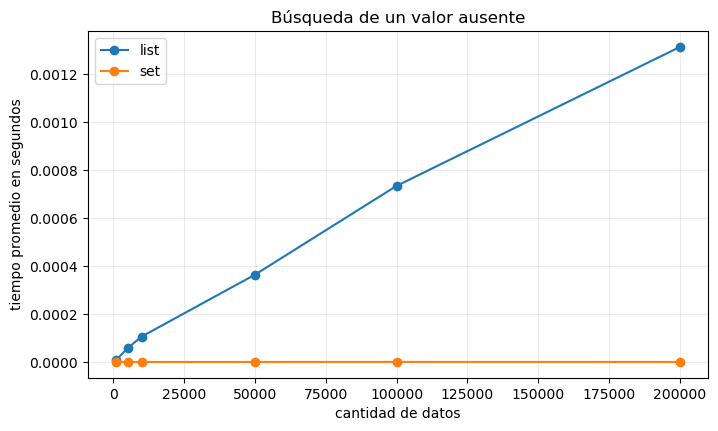

In [74]:
xs = [fila['tamano'] for fila in resultados]
ys_lista = [fila['tiempo_lista'] for fila in resultados]
ys_set = [fila['tiempo_conjunto'] for fila in resultados]

plt.figure(figsize=(8, 4.5))
plt.plot(xs, ys_lista, marker='o', label='list')
plt.plot(xs, ys_set, marker='o', label='set')
#plt.yscale('log')
plt.xlabel('cantidad de datos')
plt.ylabel('tiempo promedio en segundos')
plt.title('Búsqueda de un valor ausente')
plt.grid(True, which='both', alpha=0.25)
plt.legend()
plt.show()

### Interpretación

Responde:

1. ¿Cuál fue más rápido?
    Lo conjuntos
2. ¿La diferencia crece con el tamaño?
    En el caso de las listas si, crece bastante la canidad de tiempo dependiendo de la cantidad de datos, en el caso de los conjuntos no, se mantiene mas o menos igual todo el tiempo
3. ¿Qué estructura usarías si necesitas muchas búsquedas?
    conjuntos, porque es más rapido
4. ¿Contamos aquí el costo de construir el conjunto? ¿Por qué importa esa pregunta?
    No no lo contamos, porque contar el tiempo que nos tarda constrruir el conjunto puede subir el tiempo total que se tarda el conjunto

## 7. Conteo con diccionario

Para contar frecuencias, una representación natural es:

$$\text{valor} \mapsto \text{frecuencia}$$

In [8]:
conteos_dict = contar_con_diccionario(datos)

print(f'Valores distintos: {len(conteos_dict):,}')
print('Primeros 8 pares valor -> frecuencia:')
for valor, frecuencia in list(conteos_dict.items())[:8]:
    print(f'{valor:>5} -> {frecuencia}')

Valores distintos: 10,000
Primeros 8 pares valor -> frecuencia:
 1824 -> 8
  409 -> 8
 4506 -> 14
 4012 -> 9
 3657 -> 15
 2286 -> 15
 1679 -> 8
 8935 -> 4


## 8. Conteo con `Counter`

`Counter` es una herramienta especializada de Python para contar ocurrencias.

In [9]:
conteos_counter = contar_con_counter(datos)

print('Los 8 valores más frecuentes:')
for valor, frecuencia in conteos_counter.most_common(8):
    print(f'{valor:>5} -> {frecuencia}')

assert dict(conteos_counter) == conteos_dict
print('El diccionario y Counter representan las mismas frecuencias.')

Los 8 valores más frecuentes:
 7289 -> 24
 7779 -> 23
 4009 -> 22
 9697 -> 21
 2001 -> 21
  897 -> 21
 9376 -> 21
 5269 -> 21
El diccionario y Counter representan las mismas frecuencias.


## 9. Comparar tiempos de conteo

La diferencia no siempre será enorme. Aquí también nos interesa la claridad de la representación.

In [35]:
tiempo_dict = medir_tiempo(lambda: contar_con_diccionario(datos), repeticiones=5)
tiempo_counter = medir_tiempo(lambda: contar_con_counter(datos), repeticiones=5)

print(f'Diccionario manual: {tiempo_dict:.8f} segundos')
print(f'Counter:            {tiempo_counter:.8f} segundos')

Diccionario manual: 0.00826474 segundos
Counter:            0.00392258 segundos


### Preguntas

1. ¿Qué hace más explícito el diccionario manual?
    Como lo que hace el conjunto es indexar a las cosas con llaves, entonces lo que hace más explicito es mostrar repetidos y cosas por el estilo
2. ¿Qué hace más cómodo `Counter`?
    De igual manera se tarda un poco menos de tiempo ya que es un lenguaje compilado entonces por un lado es más rapido y por otro como counter esuna libreria de python ocupa menos lineas de codigo
3. ¿Qué estructura usarías si necesitas contar frecuencias en un texto o una simulación?
    Counterpor las ventajasya mencionadas

## 10. Complejidad intuitiva

Big-O describe cómo crece el costo cuando crece el tamaño de los datos. No es una medición exacta en segundos.

| Notación | Intuición | Ejemplo |
| --- | --- | --- |
| `O(1)` | aproximadamente constante | acceder a `datos[0]` |
| `O(n)` | proporcional al tamaño | recorrer una lista |
| `O(n²)` | doble recorrido | comparar todos contra todos |

In [86]:


def ejemplo_constante(datos):
    return datos[0]


def ejemplo_lineal(datos, objetivo):
    for dato in datos:
        if dato == objetivo:
            return True
    return False


def ejemplo_cuadratico(datos):
    total = 0
    for a in datos:
        for b in datos:
            total += a == b
    return total

def medir_tiempo(funcion, *args, **kwargs):
    inicio = time.perf_counter()
    funcion(*args,**kwargs)
    fin = time.perf_counter()
    tiempo = fin - inicio
    return tiempo


print(ejemplo_constante(datos))
print(ejemplo_lineal(datos, -1))
print(ejemplo_cuadratico(datos[:60]))

1824
False
60


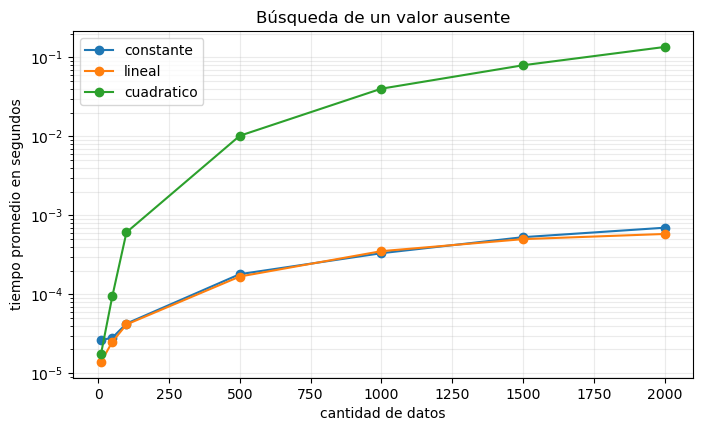

In [88]:
ejemplo = [10, 50, 100, 500, 1000, 1500, 2000]
ej_con = [medir_tiempo(lambda: ejemplo_constante(generar_datos(ejemplo[i]))) for i in range(len(ejemplo))]
ej_lin = [medir_tiempo(lambda: ejemplo_lineal(generar_datos(ejemplo[i]), -1)) for i in range(len(ejemplo))]
ej_cua = [medir_tiempo(lambda: ejemplo_cuadratico(generar_datos(ejemplo[i]))) for i in range(len(ejemplo))]

plt.figure(figsize=(8, 4.5))
plt.plot(ejemplo, ej_con, marker='o', label='constante')
plt.plot(ejemplo, ej_lin, marker='o', label='lineal')
plt.plot(ejemplo, ej_cua, marker='o', label='cuadratico')
plt.yscale('log')
plt.xlabel('cantidad de datos')
plt.ylabel('tiempo promedio en segundos')
plt.title('Búsqueda de un valor ausente')
plt.grid(True, which='both', alpha=0.25)
plt.legend()
plt.show() 

### Ejercicio

Clasifica los tres ejemplos anteriores como `O(1)`, `O(n)` u `O(n²)` y escribe una justificación breve para cada uno.

## 11. Ejercicio para completar

Cambia los tamaños y repeticiones. Observa si tu conclusión se mantiene.

In [58]:
# Puedes modificar estos valores.
tamanos_ejercicio = [2_000, 20_000, 80_000]
repeticiones_ejercicio = 6

resultados_ejercicio = comparar_busquedas_por_tamano(
    tamanos_ejercicio,
    repeticiones=repeticiones_ejercicio,
)

for fila in resultados_ejercicio:
    print(fila)

{'tamano': 2000, 'tiempo_lista': 1.7966666746360715e-05, 'tiempo_conjunto': 2.833332170363671e-07}
{'tamano': 20000, 'tiempo_lista': 0.00015428333335876232, 'tiempo_conjunto': 3.66666881745914e-07}
{'tamano': 80000, 'tiempo_lista': 0.000655833332984912, 'tiempo_conjunto': 4.5000009170811e-07}


Escribe aquí tu conclusión:

- Estructura que usaría para muchas búsquedas:
- Razón:
- Sacrificio posible:

## 12. Actividad de proyecto / GitHub

Elige o crea uno de estos issues:

- `[DOC] Escribir guía de estilo`
- `[DOC] Documentar flujo básico de GitHub`
- `[TEST] Crear primera prueba de ejemplo`
- `[PROY] Definir estructura inicial de src/`

Flujo esperado:

`Issue → Branch → Commit → Pull Request → Review → Merge`

No trabajes directamente sobre `main`.

## 13. Reflexión final

Responde:

1. ¿Cuál fue más rápido: `list` o `set` para pertenencia?
2. ¿La diferencia crece con el tamaño?
3. ¿Qué estructura usarías si necesitas muchas búsquedas?
4. ¿Qué estructura usarías si necesitas contar frecuencias?
5. ¿Qué sacrificios tiene usar un `set` en lugar de una `list`?
6. ¿Qué aprendiste al medir en lugar de solo razonar?

## 14. Reto opcional

La búsqueda en `set` es rápida, pero construir el `set` también cuesta. Mide el costo total de:

1. Construir el conjunto.
2. Hacer muchas búsquedas.

Pregunta: ¿a partir de cuántas búsquedas empieza a convenir construir el conjunto?

In [13]:
def tiempo_consultas_lista(datos, consultas):
    inicio = time.perf_counter()
    for consulta in consultas:
        consulta in datos
    return time.perf_counter() - inicio


def tiempo_construir_set_y_consultar(datos, consultas):
    inicio = time.perf_counter()
    conjunto = set(datos)
    for consulta in consultas:
        consulta in conjunto
    return time.perf_counter() - inicio


datos_reto = generar_datos(30_000)

for cantidad in [1, 10, 50, 100, 500, 1_000]:
    consultas = [-1 - i for i in range(cantidad)]
    t_lista = tiempo_consultas_lista(datos_reto, consultas)
    t_set_total = tiempo_construir_set_y_consultar(datos_reto, consultas)
    print(f'{cantidad:>5,} consultas | lista: {t_lista:.5f}s | set total: {t_set_total:.5f}s')

    1 consultas | lista: 0.00021s | set total: 0.00038s
   10 consultas | lista: 0.00234s | set total: 0.00036s
   50 consultas | lista: 0.01044s | set total: 0.00040s
  100 consultas | lista: 0.01969s | set total: 0.00034s
  500 consultas | lista: 0.09949s | set total: 0.00037s
1,000 consultas | lista: 0.19780s | set total: 0.00036s
